# **Business Case 1: Segmenting Clients**
<br>

## Goal

Here we have a random extraction of **a (real-world) dataset made up of a bank's customers**. The data is **anonymous, mostly clean and normalized in [0, 1]**.

We intend to **segment these customers using Data Science techniques** (essentially Unsupervised Machine Learning); this is a segmentation carried out from the perspective of the financial services sector.


The **dataset is called "Dataset1_BankClients"** and is saved as a .xls file.

<br>

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import numpy as np
import gower
import Utilities
from sklearn.cluster import AgglomerativeClustering

In [2]:
# Load data in a DataFrame
path = "./Dataset1_BankClients.xlsx"
data = pd.read_excel(path)
# Drop the column by its actual name (e.g., 'ID' or the actual name of the column)
data = data.drop(columns=['ID'])  # Replace 'ID' with the actual column name to drop
# Let's inspect the first 5 record
data.head()


,Age,Gender,Job,Area,CitySize,FamilySize,Income,Wealth,Debt,FinEdu,ESG,Digital,BankFriend,LifeStyle,Luxury,Saving,Investments
0,24,1,1,2,2,4,0.668046,0.702786,0.262070,0.741853,0.483684,0.698625,0.618259,0.607877,0.897369,0.283222,1
1,47,1,2,2,3,1,0.858453,0.915043,0.730430,0.859423,0.537167,0.959025,0.785936,0.862271,0.913729,0.821590,3
2,38,0,2,1,2,2,0.926818,0.898316,0.441272,0.485953,0.649434,0.750265,0.699725,0.755404,0.765199,0.503790,3
3,67,0,2,1,2,3,0.538797,0.423180,0.600401,0.493144,0.533829,0.590165,0.675353,0.334432,0.517209,0.691240,2
4,33,0,2,1,3,1,0.806659,0.731404,0.831449,0.856286,0.784940,0.710026,0.758793,0.908878,0.611610,0.615916,2


# Preparing data

### Data cleaning

Since the data is a  mix of **Numerical** and **Categorical** we need to find a proper measure to make them standard.


We have to:
* **Encode categorical variables**, so that they can be digestible by clustering algorithms - they are all trasformed in boolean variables by one-hot encoding.
* **Normalize** in [0, 1] numerical variables.

### Business Lens Analysis

Features are grouped into three business lenses capturing different aspects of the client's financial profile.

**Lens 1: Financial Capacity & Stress ("The Wallet")**
Focuses on hard financial indicators — what the client earns, owns, and owes.
Features: Income (annual earnings), Wealth (total assets), Debt (total liabilities).

**Lens 2: Bank Engagement & Literacy ("The Relationship")**
Captures how the client interacts with the financial system and the bank.
Features: FinEdu (financial education), Digital (digital adoption), BankFriend (relationship strength).

**Lens 3: Spending & Behavioral Persona ("The Choices")**
Reflects how the client allocates and uses their money.
Features: Lifestyle, Luxury, Saving, Investments, ESG.

#### Behavioral Clustering and Demographic Profiling

Clustering is performed exclusively on the **behavioral dimensions represented by the three lenses**, allowing the model to identify groups of clients who share similar financial habits and decision patterns.

**Demographic variables (e.g., Age, Gender, Job, Area, CitySize)** are not included in the clustering process. Incorporating them directly would risk forming clusters driven by location or occupation rather than genuine financial behavior.

Instead, demographics are used **after clustering** to profile and interpret the discovered personas.
For example, once a behavioral segment such as *“Aggressive Digital Investors”* emerges, demographic variables help answer questions like **where these clients tend to live, what jobs they hold, or what age groups they belong to**.

This separation ensures that clusters reflect **true behavioral patterns**, while demographics provide **context for business interpretation and strategy**.

### Distance measure

<br>

**First of all we need a proper distance** there are many distances - [Comprehensive Survey on Distance/Similarity Measures between Probability Density Functions](http://www.fisica.edu.uy/~cris/teaching/Cha_pdf_distances_2007.pdf): a suitable one is the **Gower's distance**, because it is specifically designed for mixed categorical and numerical data.

The Gower distance is the **average of all individual feature distances**. Nothing special: it ensures that each feature contributes proportionally, preventing any one type from dominating.

<br>



In [3]:
# 0. DATA CLEANING & OUTLIER REMOVAL

categorical_cols = ['Gender', 'Job', 'Area', 'CitySize', 'Investments']
continuous_cols =  [col for col in data.columns if col not in categorical_cols]
data = Utilities.find_outliers_selective(data, continuous_cols)

# DEFINE THE LENSES & DEMOGRAPHICS, THEN SPLIT

lens1_cols = ['Income', 'Wealth', 'Debt']
lens2_cols = ['FinEdu', 'Digital', 'BankFriend']
lens3_cols = ['LifeStyle', 'Luxury', 'Saving', 'Investments', 'ESG']
demo_cols = ['Age', 'Gender', 'Job', 'Area', 'CitySize', 'FamilySize']

df_lens1 = data[lens1_cols].copy()
df_lens2 = data[lens2_cols].copy()
df_lens3 = data[lens3_cols].copy()
df_demo = data[demo_cols].copy()
#df_lens3['Investments'] = df_lens3['Investments'].astype('category')
df_lens3['Investments'] = df_lens3['Investments'].astype(str)

# NORMALIZE NUMERICAL VARIABLES FOR EACH LENS
scaler = MinMaxScaler()

df_lens1_norm = Utilities.normalize_df(df_lens1, scaler)
df_lens2_norm = Utilities.normalize_df(df_lens2, scaler)
df_lens3_norm = Utilities.normalize_df(df_lens3, scaler)

# CALCULATE GOWER DISTANCE MATRIX FOR EACH LENS
gower_mat_lens1 = gower.gower_matrix(df_lens1_norm)
gower_mat_lens2 = gower.gower_matrix(df_lens2_norm)
gower_mat_lens3 = gower.gower_matrix(df_lens3_norm)

print("\nData preprocessing complete! Matrices are ready for clustering.")


Feature 'ESG' has 5 outliers.
Feature 'BankFriend' has 2 outliers.

Dropped 7 total rows.

Data preprocessing complete! Matrices are ready for clustering.


In [4]:
#  CLUSTER EACH LENS INDEPENDENTLY (Using Agglomerative)
print("Running Agglomerative clustering on distance matrices...")

# linkage='average' works best with Gower distances
agg_lens1 = AgglomerativeClustering(n_clusters=3, metric='precomputed', linkage='average')
agg_lens2 = AgglomerativeClustering(n_clusters=3, metric='precomputed', linkage='average')
agg_lens3 = AgglomerativeClustering(n_clusters=3, metric='precomputed', linkage='average')

# Fit the models and extract the cluster labels (0, 1, or 2)
labels_lens1 = agg_lens1.fit_predict(gower_mat_lens1)
labels_lens2 = agg_lens2.fit_predict(gower_mat_lens2)
labels_lens3 = agg_lens3.fit_predict(gower_mat_lens3)

print("Clustering successful!")

# BUILD THE 3D PERSONA MATRIX
# Create a final results DataFrame starting with our Demographics "Waiting Room"
df_final = df_demo.copy()

# Add the behavioral cluster labels
df_final['Lens1_Capacity'] = labels_lens1
df_final['Lens2_Engagement'] = labels_lens2
df_final['Lens3_Behavior'] = labels_lens3

# Create the "Mega-Persona" ID (e.g., "1-0-2")
df_final['Mega_Persona'] = (
    df_final['Lens1_Capacity'].astype(str) + "-" +
    df_final['Lens2_Engagement'].astype(str) + "-" +
    df_final['Lens3_Behavior'].astype(str)
)

# Calculate how many clients fall into each of the combinations
persona_counts = df_final['Mega_Persona'].value_counts().reset_index()
persona_counts.columns = ['Mega_Persona', 'Client_Count']
persona_counts['Percentage'] = (persona_counts['Client_Count'] / len(df_final)) * 100

print("\n--- TOP 5 DOMINANT MEGA-PERSONAS ---")
display(persona_counts.head(27))


Running Agglomerative clustering on distance matrices...
Clustering successful!

--- TOP 5 DOMINANT MEGA-PERSONAS ---


,Mega_Persona,Client_Count,Percentage
0,0-0-2,1472,29.481274
1,0-0-0,833,16.683357
2,0-0-1,672,13.458842
3,0-1-2,472,9.453235
4,1-0-1,461,9.232926
5,0-1-1,352,7.049870
6,1-0-0,341,6.829561
7,1-0-2,219,4.386141
8,0-1-0,124,2.483477
9,0-2-2,19,0.380533


In [5]:

# ==========================================
# 8. DEMOGRAPHIC PROFILING (The Business Value)
# ==========================================
# Let's automatically profile the #1 largest group in your matrix
top_persona_id = persona_counts.iloc[0]['Mega_Persona']
top_group_data = df_final[df_final['Mega_Persona'] == top_persona_id]

print(f"\n==========================================")
print(f"PROFILING THE DOMINANT SEGMENT: {top_persona_id}")
print(f"Total Clients: {len(top_group_data)}")
print(f"==========================================")

print("\n1. Average Demographics (Continuous):")
display(top_group_data[['Age', 'FamilySize']].mean().round(1))

print("\n2. Dominant Traits (Categorical Modes):")
categorical_demos = ['Gender', 'Job', 'Area', 'CitySize']
display(top_group_data[categorical_demos].mode().iloc[0])





PROFILING THE DOMINANT SEGMENT: 0-0-2
Total Clients: 1472

1. Average Demographics (Continuous):


Age           57.8
FamilySize     2.7
dtype: float64


2. Dominant Traits (Categorical Modes):


Gender      1
Job         2
Area        1
CitySize    2
Name: 0, dtype: int64

Generating visualizations... (t-SNE might take a minute to calculate)


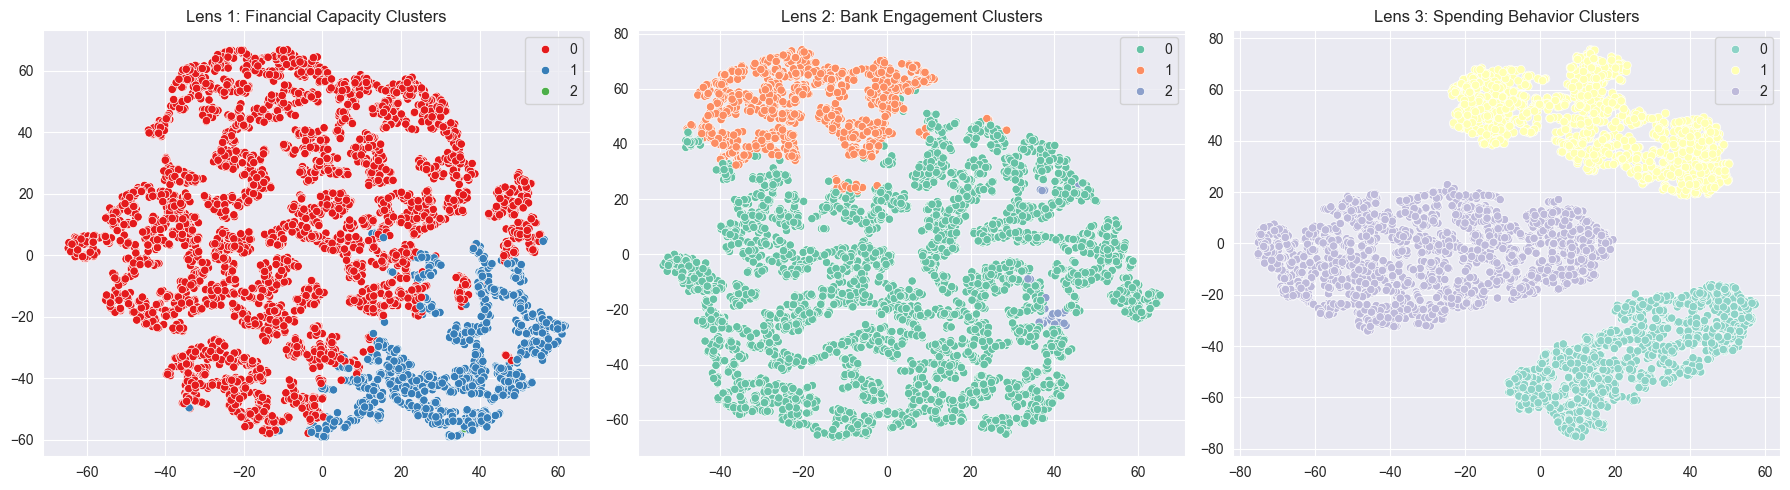

Calculating Global t-SNE...


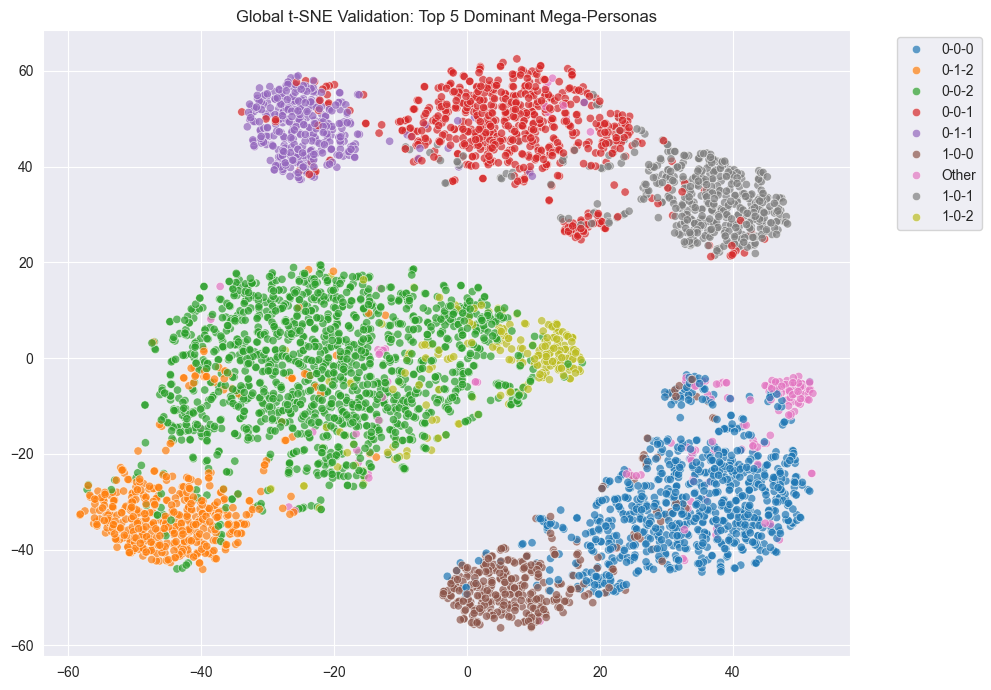

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.manifold import TSNE
import numpy as np

print("Generating visualizations... (t-SNE might take a minute to calculate)")

# ==========================================
# 1. VALIDATION: t-SNE PLOTS FOR EACH LENS
# ==========================================
# We use metric='precomputed' because we are feeding it the Gower matrices
# init='random' is required by scikit-learn when using precomputed metrics
tsne = TSNE(n_components=2, metric='precomputed', init='random', random_state=42)

# Calculate 2D coordinates for each lens
tsne_lens1 = tsne.fit_transform(gower_mat_lens1)
tsne_lens2 = tsne.fit_transform(gower_mat_lens2)
tsne_lens3 = tsne.fit_transform(gower_mat_lens3)

# Create a figure with 3 subplots side-by-side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Lens 1
sns.scatterplot(x=tsne_lens1[:, 0], y=tsne_lens1[:, 1], hue=labels_lens1, palette='Set1', ax=axes[0])
axes[0].set_title('Lens 1: Financial Capacity Clusters')

# Plot Lens 2
sns.scatterplot(x=tsne_lens2[:, 0], y=tsne_lens2[:, 1], hue=labels_lens2, palette='Set2', ax=axes[1])
axes[1].set_title('Lens 2: Bank Engagement Clusters')

# Plot Lens 3
sns.scatterplot(x=tsne_lens3[:, 0], y=tsne_lens3[:, 1], hue=labels_lens3, palette='Set3', ax=axes[2])
axes[2].set_title('Lens 3: Spending Behavior Clusters')

plt.tight_layout()
plt.show()


# ==========================================
# 2. THE 3D MATRIX OF MEGA-PERSONAS
# ==========================================
# Group by the 3 lenses to get the coordinates and the size (client count) for the bubbles
matrix_df = df_final.groupby(['Lens1_Capacity', 'Lens2_Engagement', 'Lens3_Behavior']).size().reset_index(name='Client_Count')
matrix_df['Mega_Persona'] = matrix_df['Lens1_Capacity'].astype(str) + "-" + matrix_df['Lens2_Engagement'].astype(str) + "-" + matrix_df['Lens3_Behavior'].astype(str)

# Create an interactive 3D Bubble Chart using Plotly
fig_3d = px.scatter_3d(
    matrix_df,
    x='Lens1_Capacity',
    y='Lens2_Engagement',
    z='Lens3_Behavior',
    size='Client_Count',       # Bubble size represents the number of clients
    color='Mega_Persona',      # Different color for each persona combination
    hover_name='Mega_Persona',
    title="3D Matrix of Dominant Client Personas",
    labels={
        'Lens1_Capacity': 'Capacity (0, 1, 2)',
        'Lens2_Engagement': 'Engagement (0, 1, 2)',
        'Lens3_Behavior': 'Behavior (0, 1, 2)'
    },
    opacity=0.8
)

# Force the axes to show only whole numbers (0, 1, 2)
fig_3d.update_layout(
    scene = dict(
        xaxis = dict(tickmode = 'linear', tick0 = 0, dtick = 1),
        yaxis = dict(tickmode = 'linear', tick0 = 0, dtick = 1),
        zaxis = dict(tickmode = 'linear', tick0 = 0, dtick = 1),
    )
)
fig_3d.show()


# ==========================================
# 3. GLOBAL VALIDATION: OVERALL t-SNE
# ==========================================
# To see if our Mega-Personas separate well overall, we can average our 3 distance matrices!
# This is a mathematically sound way to combine the 3 independent Gower matrices.
global_distance_matrix = (gower_mat_lens1 + gower_mat_lens2 + gower_mat_lens3) / 3

print("Calculating Global t-SNE...")
tsne_global = TSNE(n_components=2, metric='precomputed', init='random', random_state=42)
tsne_global_coords = tsne_global.fit_transform(global_distance_matrix)

# Plot the Global t-SNE, coloring only the Top 5 most dominant Mega-Personas
# (coloring all 27 makes the plot unreadable)
top_personas = persona_counts['Mega_Persona'].head(8).tolist()

# Create a column that labels a client as their persona IF they are in the Top 5, else "Other"
df_final['Plot_Label'] = df_final['Mega_Persona'].apply(lambda x: x if x in top_personas else 'Other')

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=tsne_global_coords[:, 0],
    y=tsne_global_coords[:, 1],
    hue=df_final['Plot_Label'],
    palette='tab10',
    alpha=0.7
)
plt.title("Global t-SNE Validation: Top 5 Dominant Mega-Personas")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()